In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [39]:
df = pd.read_csv("diabetes_nonlinear.csv")
print(df)
X = df[["BMI"]]
y = df[["Disease_Progression"]]

          BMI  Disease_Progression
0    0.061696                151.0
1   -0.051474                 75.0
2    0.044451                141.0
3   -0.011595                206.0
4   -0.036385                135.0
..        ...                  ...
437  0.019662                178.0
438 -0.015906                104.0
439 -0.015906                132.0
440  0.039062                220.0
441 -0.073030                 57.0

[442 rows x 2 columns]


In [16]:
# Mid Term question 3
print("Number of rows before:", len(df))
df.drop_duplicates(inplace=True)
print("Number of rows after:", len(df))

Number of rows before: 442
Number of rows after: 440


In [18]:
# Mid Term question 3 second method
print("Number of rows before:", len(df))
df.drop_duplicates(keep='first', inplace=True)
print("Number of rows after:", len(df))

Number of rows before: 442
Number of rows after: 440


In [56]:
poly = PolynomialFeatures(degree = 10)
X_poly = poly.fit_transform(X)

In [57]:
model = LinearRegression()
model.fit(X_poly,y)

LinearRegression()

In [58]:
y_pred = model.predict(X_poly)

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y,y_pred)

print("Meab Squared Error (MSE):", mse)
print("R2 Score", r2)

Meab Squared Error (MSE): 3794.198278040249
R2 Score 0.3601565048898132


/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


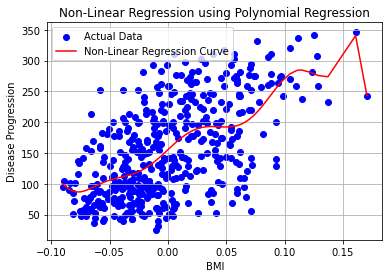

In [60]:
X_sorted = np.sort(X, axis=0)
Y_sorted_pred = model.predict(poly.transform(X_sorted))

plt.scatter(X.values.flatten(), y.values.flatten(), color="blue", label="Actual Data")
plt.plot(X_sorted.flatten(), Y_sorted_pred.flatten(), color="red", label="Non-Linear Regression Curve")

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Non-Linear Regression using Polynomial Regression")
plt.legend()
plt.grid()

In [35]:
new_bmi = [[0.05]]
new_bmi_poly = poly.transform(new_bmi)
prediction_disease = model.predict(new_bmi_poly)

print("Predicated Disease Progression:", prediction_disease)

Predicated Disease Progression: [[201.59950508]]


/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
